In [7]:
import sys
import glob
import pickle
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("code")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")


import Chronocell
from impute_protein import *
from protein_from_RNA import *

In [8]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5_204_fitted_genes"

In [9]:
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

# Names of genes in Chronocell object
genes = pd.read_csv(f"data/{prefix}.csv")

In [10]:
sampleinfo = pd.read_csv(f"data/{prefix}_sampleinfo_barcode_level.csv")

# orig_corr = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")

expr_ADT_imputed = pd.read_csv(f"data/{prefix}_RNA_history_imputed_protein.csv")
expr_ADT = pd.read_csv("data/janssens_2025_preprint_author_ADT_counts_eLNP.csv", index_col=0)
expr_RNA = pd.read_csv("data/janssens_2025_preprint_author_RNA_counts_eLNP.csv", index_col=0)

In [11]:
# Subset to genes of interest

# orig_corr = orig_corr.loc[orig_corr['Gene'].isin(expr_ADT_imputed.columns)]

In [12]:
t = traj.t
Q = traj.Q[:, 0, :] 

In [13]:
# Make sure order of cells matches

In [14]:
expr_ADT_imputed.index = sampleinfo['Cell_ID']

expr_ADT.index = expr_ADT.index.str.replace("-1", "", regex=False)
expr_ADT.index = expr_ADT.index.str.replace("_", "-", regex=False)

expr_RNA.index = expr_RNA.index.str.replace("-1", "", regex=False)
expr_RNA.index = expr_RNA.index.str.replace("_", "-", regex=False)

In [15]:
expr_RNA = expr_RNA.loc[expr_ADT_imputed.index]
expr_ADT = expr_ADT.loc[expr_ADT_imputed.index]

In [16]:
np.all(expr_ADT_imputed.index == expr_ADT.index)

np.True_

In [17]:
np.all(expr_ADT_imputed.index == expr_RNA.index)

np.True_

In [18]:
# Order cells by their inferred place in time

In [19]:
Q_max_idx = np.argmax(Q, axis=1)

cell_order_idx = np.argsort(Q_max_idx)
cell_index = expr_ADT.index[cell_order_idx]

expr_ADT_ordered = expr_ADT.loc[cell_index]
expr_RNA_ordered = expr_RNA.loc[cell_index]
expr_ADT_imputed_ordered = expr_ADT_imputed.loc[cell_index]

In [20]:
# Time point per cell for plotting

t_per_cell = t[np.sort(Q_max_idx)]

In [21]:
prot = "CD63"
gene = "Cd63"

In [22]:
# Load imputed RNA for working gene

file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw = pickle.load(f)
    
X_bw_ordered = X_bw[cell_order_idx, :]
Q_max_idx_ordered = Q_max_idx[cell_order_idx]

In [23]:
# Subset to end cell to get whole trajectory
end_cells_idx = np.where(Q_max_idx_ordered == 99)[0]
end_cells_idx

array([20199, 20200, 20201, ..., 21322, 21323, 21324])

In [24]:
# Plot imputed RNA and protein for various cells

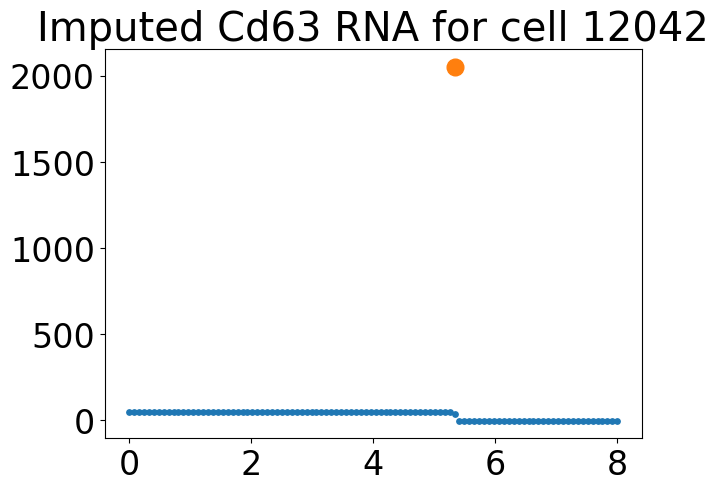

In [25]:
idx = expr_ADT_imputed_ordered.loc[:, gene].argmax()

plt.scatter(
    t,
    X_bw_ordered[idx, :],
    s=15
)
plt.scatter(
    t[Q_max_idx_ordered[idx]],
    expr_ADT_imputed_ordered.iloc[idx].loc[gene]
)
plt.title(f"Imputed {gene} RNA for cell {idx}");

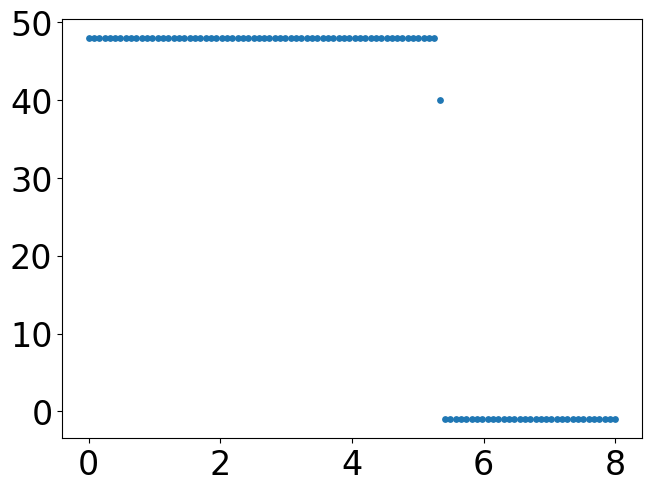

In [26]:
idx = expr_ADT_imputed_ordered.loc[:, gene].argmax()

plt.scatter(
    t,
    X_bw_ordered[idx, :],
    s=15
)

Text(0.5, 1.0, 'Imputed Cd63 RNA for cell 21241')

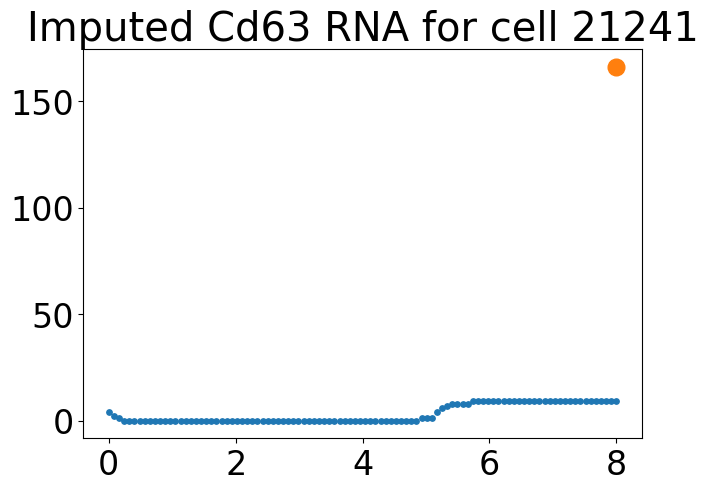

In [27]:
idx = -1

plt.scatter(
    t,
    X_bw_ordered[idx, :],
    s=15
)
plt.scatter(
    t[Q_max_idx_ordered[idx]],
    expr_ADT_imputed_ordered.iloc[idx].loc[gene]
)
plt.title(f"Imputed {gene} RNA for cell {cell_order_idx[idx]}")

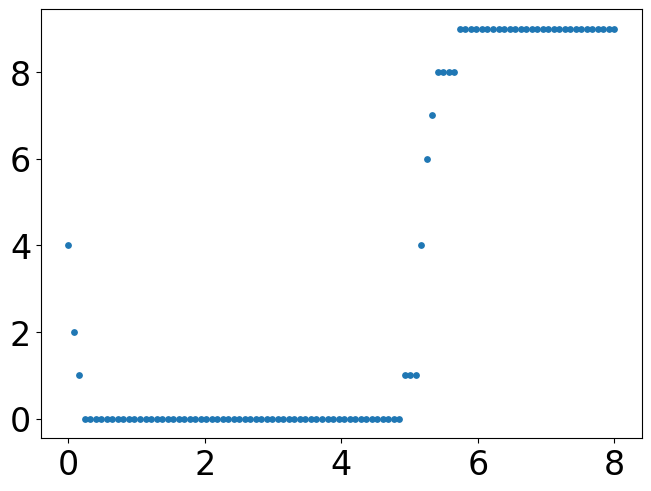

In [28]:
idx = -1

plt.scatter(
    t,
    X_bw_ordered[idx, :],
    s=15
)

In [29]:
recon_RNA = X_bw_ordered[:, 0:5]
recon_RNA [recon_RNA >= 0]

array([ 3, 17, 11, ...,  1,  0,  0])

In [30]:
t[5]

np.float64(0.4040404040404041)

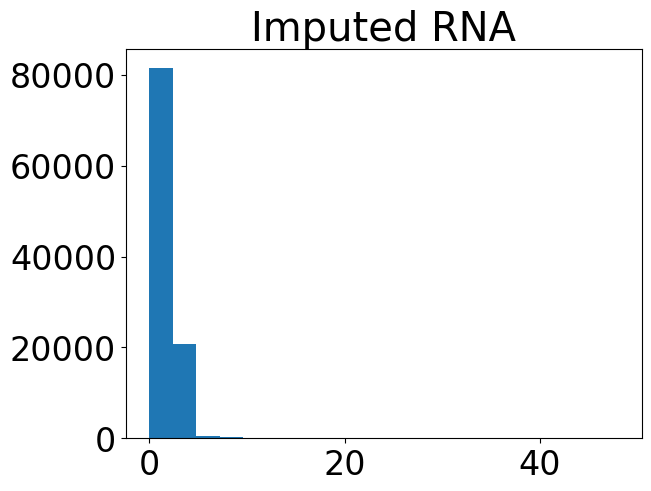

In [31]:
plt.hist(recon_RNA[recon_RNA >= 0], bins=20);
plt.title("Imputed RNA");

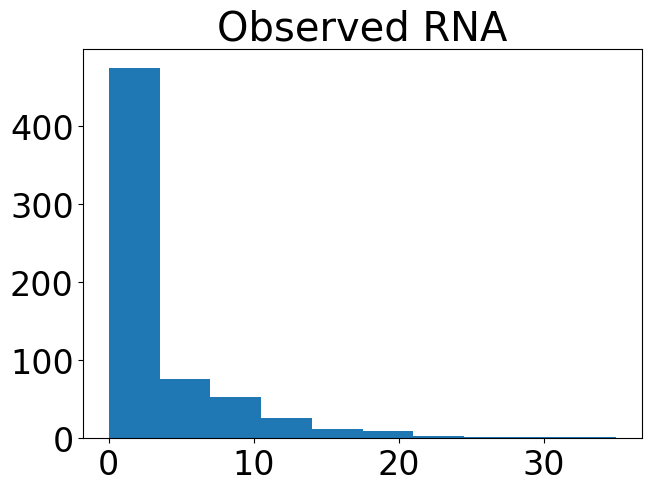

In [32]:
plt.hist(expr_RNA_ordered[gene][(t_per_cell > 0) & (t_per_cell < 0.5)]);
plt.title("Observed RNA");

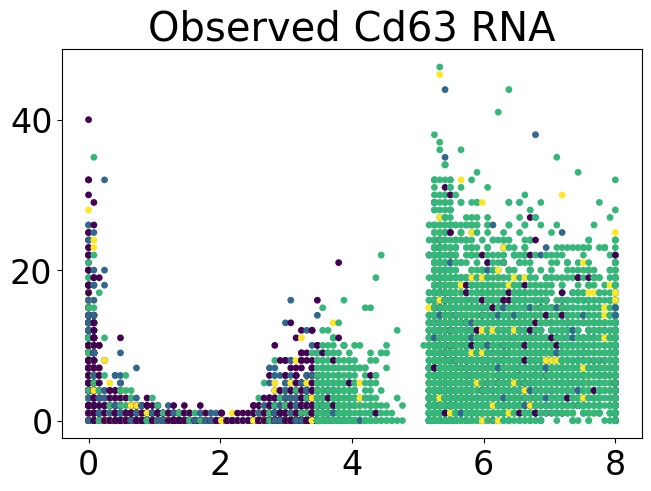

In [33]:
plt.scatter(
    t_per_cell,
    expr_RNA_ordered[gene],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=15
)
plt.title(f"Observed {gene} RNA");

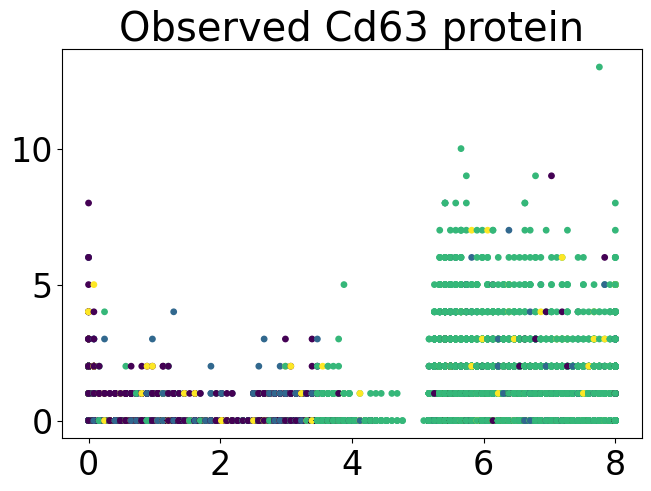

In [34]:
plt.scatter(
    t_per_cell,
    expr_ADT_ordered[prot],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=15
)
plt.title(f"Observed {gene} protein");

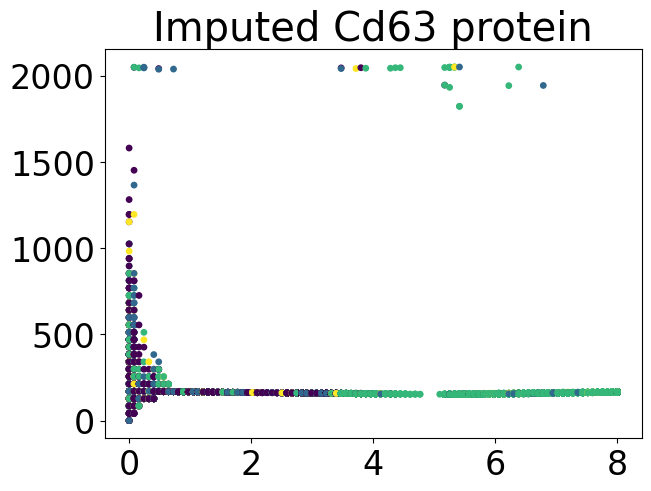

In [35]:
plt.scatter(
    t_per_cell,
    expr_ADT_imputed_ordered[gene],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=15
)
plt.title(f"Imputed {gene} protein");

In [36]:
# Now let's try simulating protein using reconstructed RNA and kinetic parameters for the working gene

In [37]:
tau = traj.tau # State transition times (global)
topo = traj.topo
true_t = traj.t
true_l = np.repeat(0, len(t)) 

In [38]:
# Get deg. rate for gene of interst

data_dir = "/mnt/lareaulab/reliscu/projects/Chronocell/data/experimental_parameters/protein_degradation_rates"
file_list = glob.glob(f"{data_dir}/*standardized.csv")
subset_columns = ['Gene', 'Half-life']

df_list = []
for file in [file for file in file_list if "Mouse" in file]:
    df = pd.read_csv(file)
    study = df['Study'].iloc[0]
    cell_type = df['Cell_type'].iloc[0]
    df = df[subset_columns]
    df = df.rename(columns={"Half-life": f"Half-life_{study}_{cell_type}", 
                            "Cell_type": f"Cell_type_{study}"}) 
    df_list.append(df)
    
df = reduce(lambda x, y: pd.merge(x, y, on="Gene", how="outer"), df_list)

half_life_cols = [col for col in df.columns if "Half-life" in col]
df_deg = np.log(2)/df[half_life_cols]
median_deg = np.nanmedian(df_deg, axis=1)

In [39]:
deg_rate = median_deg[np.where(df['Gene'] == gene)[0][0]]
deg_rate

np.float64(0.023397355708481997)

In [40]:
phi = np.zeros((1, 2))
phi[:,0] = 1
phi[:,-1] = deg_rate

In [41]:
# Load imputed RNA for working gene

file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_S_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw_S = pickle.load(f)
    
file_path = f"data/RNA_history_per_gene/{prefix}_{gene}_U_RNA_history.pkl"

with open(file_path, "rb") as f:
    X_bw_U = pickle.load(f)

In [42]:
X_bw_S_ordered = X_bw_S[cell_order_idx, :]
X_bw_U_ordered = X_bw_U[cell_order_idx, :]

In [43]:
# Get average imputed protein value for these cells

In [44]:
earlier_time_cts = X_bw_S_ordered[:, :3]

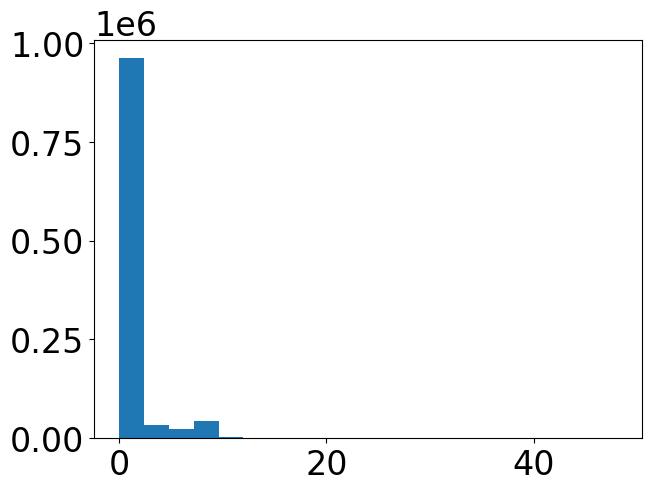

In [45]:
later_time_cts = X_bw_S_ordered[:, :75]

plt.hist(later_time_cts[later_time_cts >= 0], bins=20);

In [46]:
def simulate_protein_from_RNA(Y, topo, true_t, true_l, phi, step_size, random_seed=0):
    ## phi: Protein params
    np.random.seed(random_seed)
    
    L = len(topo) # No. lineages
    n = Y.shape[0] // L # No. cells per lineage
    p = Y.shape[1] # No. genes
    
    y0 = Y[0, :, 1] # RNA abundance per gene at state 0
    ss_rate = phi[:, 0] / phi[:, -1] # Steady-state protein production rate = transl_rate/deg_rate
    p0 = ss_rate * y0 # Initial protein abundance assuming steady-state
    print("y0:", y0)
   
    # Protein production paramters:
    transl_rates = phi[:, 0].T
    deg_rates = phi[:, -1].reshape((1, -1))
    
    P = np.zeros((n*L, p))
    
    for l in range(L):
        t_l = true_t[true_l == l] # Time points/cells in lineage l     
        dt = np.repeat(step_size, len(t_l)) # np.diff(t_l, prepend=-t_l[1]) # Time step size for each cell along the trajectory
        t_l = t_l.reshape((-1, 1)) 
        y_l = Y[l*n:(l+1)*n, :, 1] # Spliced RNAs for lineage l
        
        p_l = p0 * np.exp(-deg_rates * t_l) # Pre-existing protein that has not yet degraded
        print("p_old:", p_l[-1])
        
        t_diff = t_l - t_l.T # Rows = target time; columns = past times; e.g. t_diff[m, i] = time difference between t_m and t_i 
        decay_matrix = np.exp(-t_diff[:, :, None] * deg_rates) # Decay_matrix[m, i, p] = decay factor for protein abundance at t_m from RNA available at t_i for gene p
        mask = (t_diff >= 0)[:, :, None]
        mask = np.broadcast_to(mask, decay_matrix.shape)
        decay_matrix = np.where(mask, decay_matrix, 0) # Protein abundance at time t_m can't come from RNA at time t_i > t_m
        
        y_l_dt = y_l * dt[:, None] # Multiply each timepoint's RNA by its corresponding time step size (Riemann approximation)
        # Note to self: protein produced from RNA from time t = m can only be produced during the interval it was measured over, hence: scale RNA contribution at that time step by its time step size
        protein_contrib = (decay_matrix * y_l_dt[None, :, :]).sum(axis=1) # Integrate RNA counts still surviving up to each time point
        # Note to self: protein_contrib[target_idx, gene_idx] = np.sum(decay_matrix[target_time, :(target_time + 1), gene_idx] * y_l_dt[None, :(target_time + 1), gene_idx])
        P[l*n:(l+1)*n] = p_l + transl_rates * protein_contrib # Protein abundance in each cell = pre-existing protein + newly synthesized protein
        print("p_new:", (transl_rates * protein_contrib)[-1])
        print("P:", P[l*n:(l+1)*n][-1])
         
    P_observed = np.random.poisson(P)
        
    return P_observed, P, y0

In [47]:
step_size = t[1] - t[0]

In [48]:
subset_idx = np.where(t_per_cell <= 0.3)[0]

In [49]:
P_curr = []
y0_imputed = []

for idx in subset_idx:
    print("===============")
    t_idx = np.where(true_t == t_per_cell[idx])[0][0]
    print("Inferfed t:", t[t_idx])
    
    u = X_bw_U_ordered[idx, :t_idx] if t_idx > 0 else X_bw_U_ordered[idx, :1]
    s = X_bw_S_ordered[idx, :t_idx] if t_idx > 0 else X_bw_S_ordered[idx, :1]
    
    if t_idx == 0:
        tt, tl = true_t[t_idx], true_l[t_idx]
    else:
        tt, tl = true_t[:t_idx], true_l[:t_idx]
        
    Y = np.empty((u.shape[0], 1, 2))
    Y[:, :, 0] = u[:, None]
    Y[:, :, 1] = s[:, None]

    # plt.scatter(t[:t_idx], X_bw_S_ordered[idx, :t_idx])
    # plt.title(f"Imputed RNA trajectory for cell at t = {np.round(t[t_idx], 2)}");
    
    # plt.scatter(true_t[:t_idx], P, s=3)
    
    P_observed, P, y0 = simulate_protein_from_RNA(Y, topo, tt, tl, phi, step_size, random_seed=0);
    
    P_curr.append(P[-1, :][0])
    y0_imputed.append(y0[0])

Inferfed t: 0.0
y0: [3.]
p_old: [128.21961752]
p_new: [0.24242424]
P: [128.46204177]
Inferfed t: 0.0
y0: [17.]
p_old: [726.57783263]
p_new: [1.37373737]
P: [727.95157001]
Inferfed t: 0.0
y0: [11.]
p_old: [470.13859759]
p_new: [0.88888889]
P: [471.02748647]
Inferfed t: 0.0
y0: [4.]
p_old: [170.95949003]
p_new: [0.32323232]
P: [171.28272235]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]
P: [385.3861253]
Inferfed t: 0.0
y0: [5.]
p_old: [213.69936254]
p_new: [0.4040404]
P: [214.10340294]
Inferfed t: 0.0
y0: [12.]
p_old: [512.87847009]
p_new: [0.96969697]
P: [513.84816706]
Inferfed t: 0.0
y0: [3.]
p_old: [128.21961752]
p_new: [0.24242424]
P: [128.46204177]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]
P: [385.3861253]
Inferfed t: 0.0
y0: [13.]
p_old: [555.6183426]
p_new: [1.05050505]
P: [556.66884765]
Inferfed t: 0.0
y0: [2.]
p_old: [85.47974502]
p_new: [0.16161616]
P: [85.64136118]
Inferfed t: 0.0
y0: [9.]
p_old: [384.65885257]
p_new: [0.72727273]


# How do these estimates compare to what I imputed earlier?

In [54]:
expr_ADT_imputed_ordered[gene].iloc[subset_idx]

Cell_ID
CACACAATCGGACAAG-2    128
CACATGAGTCGTTATG-2    726
CACATGATCGAGAAAT-2    470
GCATCTCGTGAGCAGT-2    170
GCGAGAAAGAGGGCGA-2    384
                     ... 
AGCCACGGTGAGTGAC-2    127
GTTACGAAGCGTCTCG-6    127
GTTCGCTCACGTAACT-6    127
TGTCCACGTTCGTGCG-2    127
AGACAGGCACCTCGTT-6    512
Name: Cd63, Length: 961, dtype: int64

In [55]:
np.corrcoef(expr_ADT_imputed_ordered[gene].iloc[subset_idx], P_curr)

array([[1.        , 0.99999924],
       [0.99999924, 1.        ]])

# Almost identitical.

### It looks like the issue is that cells from later in the trajectory all have RNA abundances that are the same since they revert to the mean by that point. Cells earlier in the trajectory still retain some variability, so many more cells have larger starting RNA abundances, hence higher imputed protein levels

(array([160., 186., 241., 139.,  75.,  72.,  36.,  21.,   9.,   4.,   3.,
          5.,   1.,   1.,   1.,   1.,   0.,   0.,   0.,   6.]),
 array([ 0. ,  2.4,  4.8,  7.2,  9.6, 12. , 14.4, 16.8, 19.2, 21.6, 24. ,
        26.4, 28.8, 31.2, 33.6, 36. , 38.4, 40.8, 43.2, 45.6, 48. ]),
 <BarContainer object of 20 artists>)

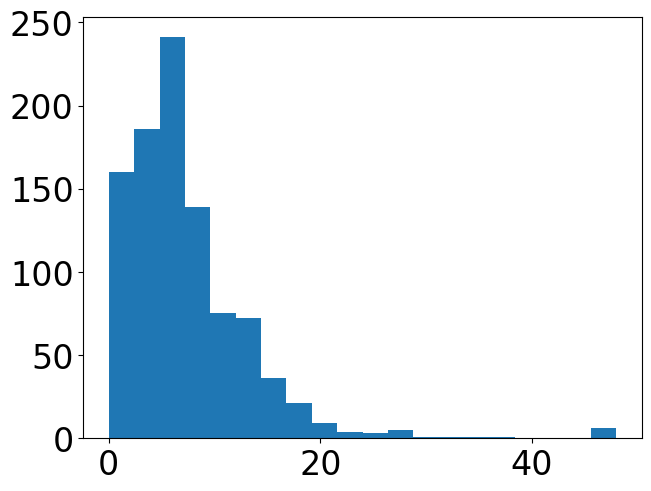

In [ ]:
plt.hist(y0_imputed, bins=20);

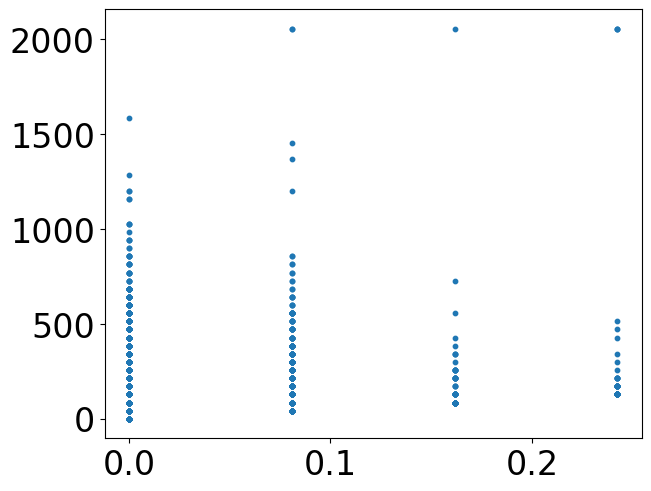

In [772]:
plt.scatter(t_per_cell[subset_idx], P_curr, s=10)

In [773]:
subset_idx = np.where(t_per_cell > 6)[0]

In [774]:
P_curr = []
y0_imputed = []

for idx in subset_idx:
    print("===============")
    t_idx = np.where(true_t == t_per_cell[idx])[0][0]
    print("Inferfed t:", t[t_idx])
    
    u = X_bw_U_ordered[idx, :t_idx] if t_idx > 0 else X_bw_U_ordered[idx, :1]
    s = X_bw_S_ordered[idx, :t_idx] if t_idx > 0 else X_bw_S_ordered[idx, :1]
    
    if t_idx == 0:
        tt, tl = true_t[t_idx], true_l[t_idx]
    else:
        tt, tl = true_t[:t_idx], true_l[:t_idx]
        
    Y = np.empty((u.shape[0], 1, 2))
    Y[:, :, 0] = u[:, None]
    Y[:, :, 1] = s[:, None]

    # plt.scatter(t[:t_idx], X_bw_S_ordered[idx, :t_idx])
    # plt.title(f"Imputed RNA trajectory for cell at t = {np.round(t[t_idx], 2)}");
    
    # plt.scatter(true_t[:t_idx], P, s=3)
    
    P_observed, P, y0 = simulate_protein_from_RNA(Y, topo, tt, tl, phi, step_size, random_seed=0);
    
    P_curr.append(P[-1, :][0])
    y0_imputed.append(y0[0])

Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.73374818]
P: [155.37194854]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.97571479]
P: [155.61391515]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.97571479]
P: [155.61391515]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.97571479]
P: [155.61391515]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [7.13717831]
P: [155.77537867]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [8.10413382]
P: [156.74233419]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [8.5074119]
P: [157.14561226]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.6529401]
P: [155.29114046]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [6.97571479]
P: [155.61391515]
Inferfed t: 6.060606060606061
y0: [4.]
p_old: [148.63820036]
p_new: [7.13717831]
P: [155.77537867]
Inferfed t: 

In [776]:
y0_imputed

[np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float64(4.0),
 np.float6

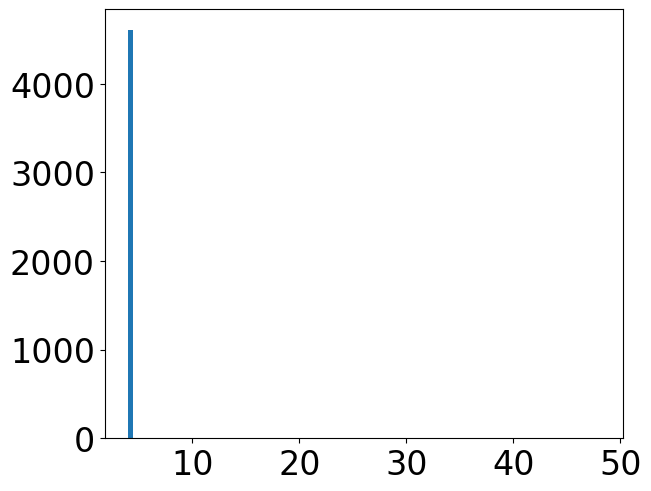

In [777]:
plt.hist(y0_imputed, bins=100);

In [317]:
idx = 20 

P_observed, P = simulate_protein_from_RNA(Y[:idx, :, :], topo, true_t[:idx], true_l[0:idx], phi, random_seed=0)

p0: [170.95949003]
p_old: [164.92707644]
p_old: [165.47336386]
transl_rates * protein_contrib: [0.54628742]


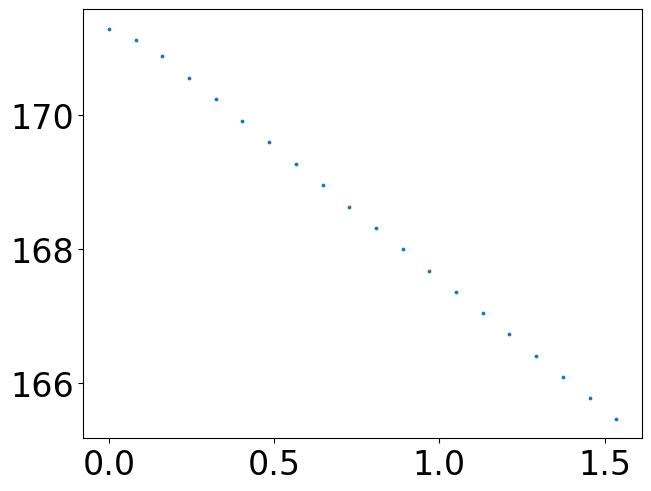

In [318]:
plt.scatter(true_t[:idx], P, s=3)

In [319]:
P[-1, :]

array([165.47336386])

In [247]:
Q_max_idx = np.argmax(Q, axis=1) # Each cell's time along the trajectory

y0 = X_bw_S_ordered[-1, 0] # Steady-state RNA abundance
ss_rate = 1 / deg_rate # Steady-state protein production rate 
p0 = ss_rate * y0 # Steady-state protein abundance
p_old = p0 * np.exp(-deg_rate * t[-1]) # Pre-existing protein that has not yet degraded at the time each cell was observed


In [271]:
p_old

np.float64(141.7759199053753)

In [255]:

t_reshape = t.reshape((-1, 1))
t_diff = t_reshape.T - t_reshape
t_diff = t_diff[:, -1] # Each column corresponds to a cell: contains time steps with cumulative duration of time leading up to its observed time


In [256]:

decay_matrix = np.exp(-t_diff * deg_rate) # Decay_matrix[i, m] = decay factor for protein made from RNA available at t_i in cell m
mask = (t_diff >= 0) # Protein abundance at time t_m can't come from RNA at time t_i > t_m (cell's observed time)
mask = np.broadcast_to(mask, decay_matrix.shape)
decay_matrix = np.where(mask, decay_matrix, 0) 


In [257]:
decay_matrix

array([0.82929541, 0.83086484, 0.83243723, 0.83401261, 0.83559096,
       0.83717231, 0.83875664, 0.84034397, 0.84193431, 0.84352766,
       0.84512402, 0.8467234 , 0.84832582, 0.84993126, 0.85153974,
       0.85315126, 0.85476584, 0.85638347, 0.85800416, 0.85962792,
       0.86125475, 0.86288466, 0.86451766, 0.86615375, 0.86779293,
       0.86943521, 0.8710806 , 0.87272911, 0.87438074, 0.87603549,
       0.87769337, 0.87935439, 0.88101855, 0.88268587, 0.88435634,
       0.88602997, 0.88770676, 0.88938674, 0.89106989, 0.89275622,
       0.89444575, 0.89613847, 0.8978344 , 0.89953354, 0.90123589,
       0.90294146, 0.90465027, 0.9063623 , 0.90807758, 0.9097961 ,
       0.91151787, 0.91324291, 0.9149712 , 0.91670277, 0.91843762,
       0.92017575, 0.92191716, 0.92366188, 0.92540989, 0.92716122,
       0.92891585, 0.93067381, 0.9324351 , 0.93419972, 0.93596767,
       0.93773898, 0.93951363, 0.94129165, 0.94307303, 0.94485778,
       0.94664591, 0.94843742, 0.95023232, 0.95203062, 0.95383

In [265]:

dt = np.diff(t, prepend=-t[1])
X_bw_dt = X_bw_S_ordered[-1, :] * dt # Multiply each timepoint's RNA by its corresponding time step size (Riemann approximation) 
X_bw_dt[X_bw_dt < 0] = 0 # X_bw was populated with '-1' for time points after the cell was observed


In [267]:
X_bw_S_ordered[-1, :]

array([4, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 4, 6,
       7, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
       9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9])

In [268]:
X_bw_dt

array([0.32323232, 0.16161616, 0.08080808, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.08080808, 0.08080808, 0.08080808, 0.32323232,
       0.48484848, 0.56565657, 0.64646465, 0.64646465, 0.64646465,
       0.64646465, 0.72727273, 0.72727273, 0.72727273, 0.72727

In [269]:

p_new = (decay_matrix * X_bw_dt.T).sum(axis=0) # Integrate RNA counts still surviving up to each time point (until the cell was observed)
P = p_old + p_new # Protein abundance in each cell = pre-existing protein + newly synthesized protein

In [270]:
P

np.float64(166.74370489915185)